# Student Academic Outcome — Exploratory Data Analysis
## Statistical Learning and Data Analysis — Assignment 1

---

## 1. Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load the dataset
df = pd.read_csv("D:\Projects\STATISTIC ASSIGNMENTS\ASSIGNMENT-1\Dataset\Student Academic Outcome Prediction Data.csv", sep=';')
df.columns = df.columns.str.strip()
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head(5)

Dataset loaded successfully!
Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# Variable names and data types
print("=== Variable Names and Data Types ===")
print(df.dtypes)
print(f"\nNumeric columns : {df.select_dtypes(include=np.number).shape[1]}")
print(f"Object  columns : {df.select_dtypes(include='object').shape[1]}")

=== Variable Names and Data Types ===
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date           

In [4]:
# Number of observations and variables
print(f"Observations : {df.shape[0]}")
print(f"Variables    : {df.shape[1]}")

Observations : 4424
Variables    : 37


In [5]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("No missing values found in any column.")
    print("\nDecision: No imputation or removal required.")
    print("The dataset is complete and can be used directly for analysis.")
else:
    print("Missing values detected:")
    print(missing_df)

No missing values found in any column.

Decision: No imputation or removal required.
The dataset is complete and can be used directly for analysis.


**Section 1 Commentary:**
The dataset contains 4,424 students and 36 features covering academic performance, demographics, and socioeconomic background. All variables are numeric — the dataset encodes categorical information (e.g. gender, scholarship status) as binary integers (0/1). The only true text variable is the target `Target`. There are no missing values in any column, so no imputation or removal is needed. The data is ready for analysis as-is.

## 2. Univariate Data Description

In [6]:
# Descriptive statistics for all numeric variables
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].describe().round(2)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,10.96,11.03,126.98,0.55,0.01,0.11,0.88,0.35,0.25,23.27,0.02,0.71,6.27,8.30,4.71,10.64,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,26.42,25.26,14.48,0.50,0.11,0.32,0.32,0.48,0.43,7.59,0.16,2.36,2.48,4.18,3.09,4.84,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,0.00,0.00,95.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,4.00,4.00,117.90,0.00,0.00,0.00,1.00,0.00,0.00,19.00,0.00,0.00,5.00,6.00,3.00,11.00,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,5.00,7.00,126.10,1.00,0.00,0.00,1.00,0.00,0.00,20.00,0.00,0.00,6.00,8.00,5.00,12.29,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,9.00,9.00,134.80,1.00,0.00,0.00,1.00,1.00,0.00,25.00,0.00,0.00,7.00,10.00,6.00,13.40,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,194.00,195.00,190.00,1.00,1.00,1.00,1.00,1.00,1.00,70.00,1.00,20.00,26.00,45.00,26.00,18.88,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


In [7]:
# Frequency tables for categorical / binary variables
categorical_features = ['Target', 'Gender', 'Scholarship holder', 'Debtor',
                         'Tuition fees up to date', 'Displaced', 'International']

for col in categorical_features:
    counts = df[col].value_counts()
    pct    = (counts / len(df) * 100).round(2)
    freq_table = pd.DataFrame({'Count': counts, 'Percentage (%)': pct})
    print(f"\n=== {col} ===")
    print(freq_table)


=== Target ===
          Count  Percentage (%)
Target                         
Graduate   2209           49.93
Dropout    1421           32.12
Enrolled    794           17.95

=== Gender ===
        Count  Percentage (%)
Gender                       
0        2868           64.83
1        1556           35.17

=== Scholarship holder ===
                    Count  Percentage (%)
Scholarship holder                       
0                    3325           75.16
1                    1099           24.84

=== Debtor ===
        Count  Percentage (%)
Debtor                       
0        3921           88.63
1         503           11.37

=== Tuition fees up to date ===
                         Count  Percentage (%)
Tuition fees up to date                       
1                         3896           88.07
0                          528           11.93

=== Displaced ===
           Count  Percentage (%)
Displaced                       
1           2426           54.84
0           1998 

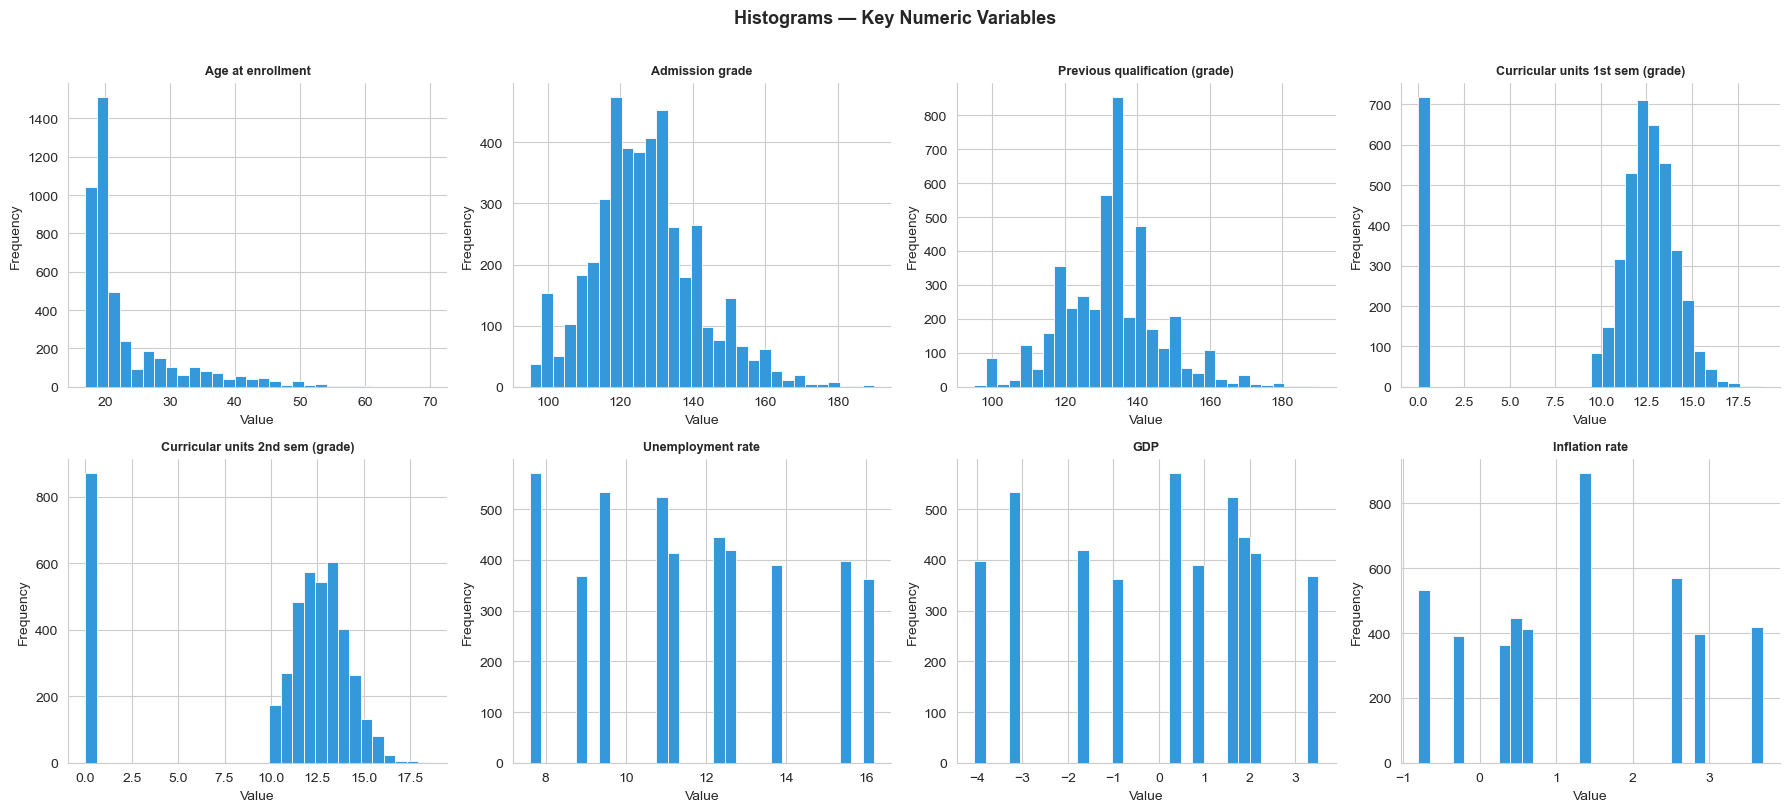

In [8]:
# Histograms for key numeric variables
key_num = ['Age at enrollment', 'Admission grade', 'Previous qualification (grade)',
           'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
           'Unemployment rate', 'GDP', 'Inflation rate']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_num):
    axes[i].hist(df[col].dropna(), bins=30, color='#3498db', edgecolor='white', linewidth=0.6)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Histograms — Key Numeric Variables', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

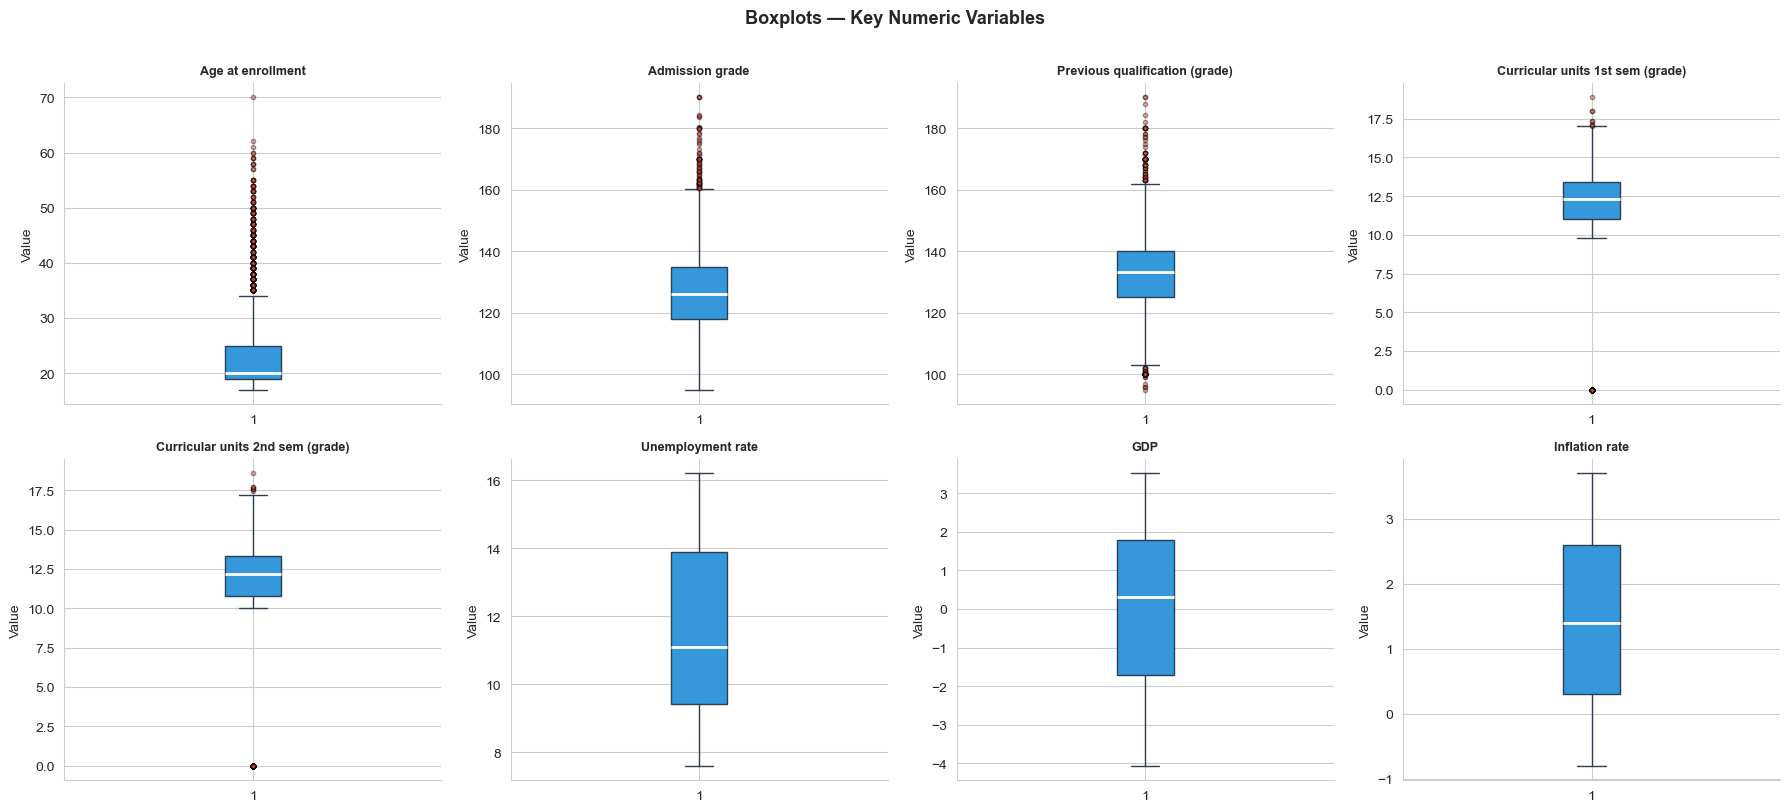

In [9]:
# Boxplots for key numeric variables
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_num):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', color='#2c3e50'),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#2c3e50'),
                    capprops=dict(color='#2c3e50'),
                    flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Boxplots — Key Numeric Variables', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

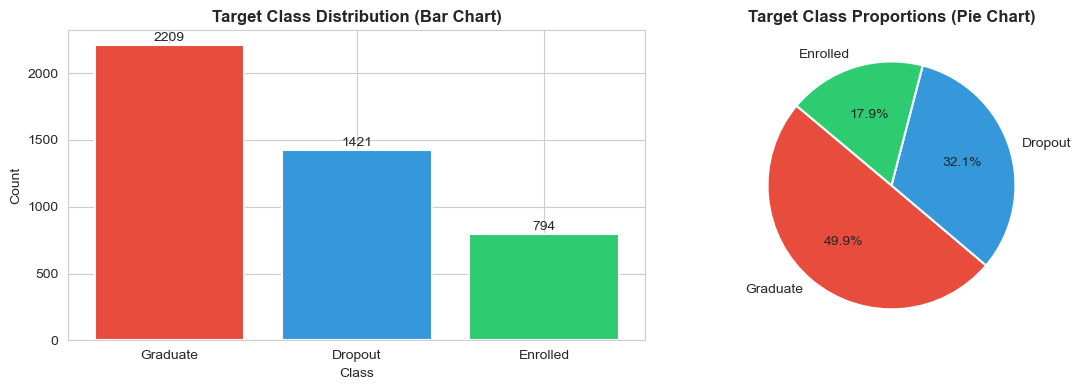

Most frequent class: Graduate (2209 students, 49.9%)


In [10]:
# Bar chart and pie chart for Target variable (most important categorical)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['Target'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']

axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution (Bar Chart)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(target_counts.items()):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=10)

axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Target Class Proportions (Pie Chart)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Most frequent class: {target_counts.idxmax()} ({target_counts.max()} students, {target_counts.max()/len(df)*100:.1f}%)")

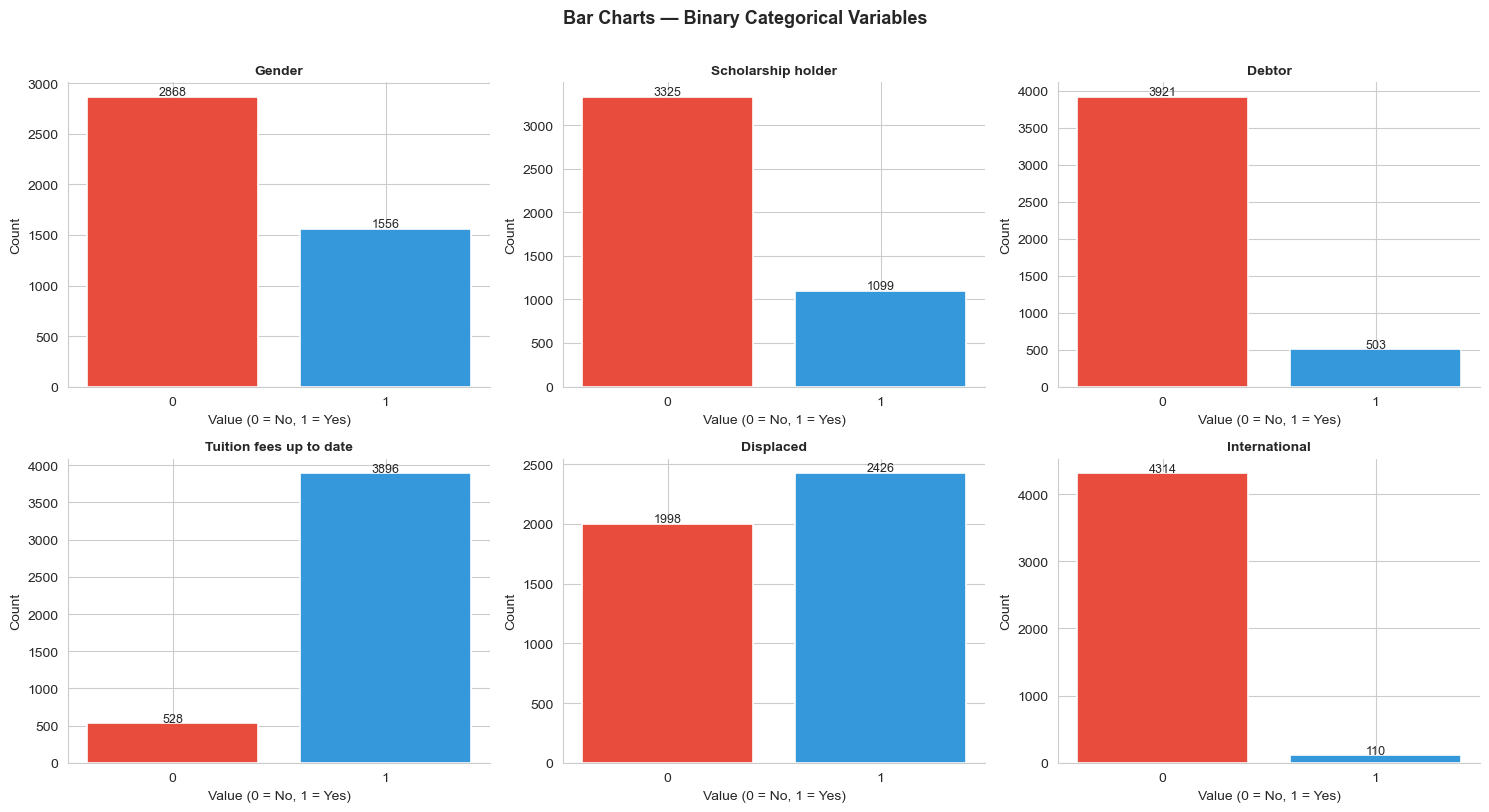

In [11]:
# Bar charts for binary categorical variables
binary_features = ['Gender', 'Scholarship holder', 'Debtor', 'Tuition fees up to date',
                   'Displaced', 'International']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(binary_features):
    counts = df[feat].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color=['#e74c3c','#3498db'],
                edgecolor='white', linewidth=1.2)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value (0 = No, 1 = Yes)')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 20, str(v), ha='center', fontsize=9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Bar Charts — Binary Categorical Variables', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Section 2 Commentary:**
Admission grades and previous qualification grades are roughly bell-shaped and centred around 120–130. Semester grades show a right-skewed distribution with a large spike at zero, reflecting students who enrolled but did not complete any units — predominantly dropouts. Age at enrollment is right-skewed with most students enrolling between 18 and 25. GDP and unemployment rate show limited variation, clustering around typical Portuguese macroeconomic values. Among categorical variables, Graduate is the most frequent class (~49%), followed by Dropout (~32%) and Enrolled (~19%). The majority of students are not scholarship holders and have their tuition fees up to date.

## 3. Bivariate and Multivariate Description

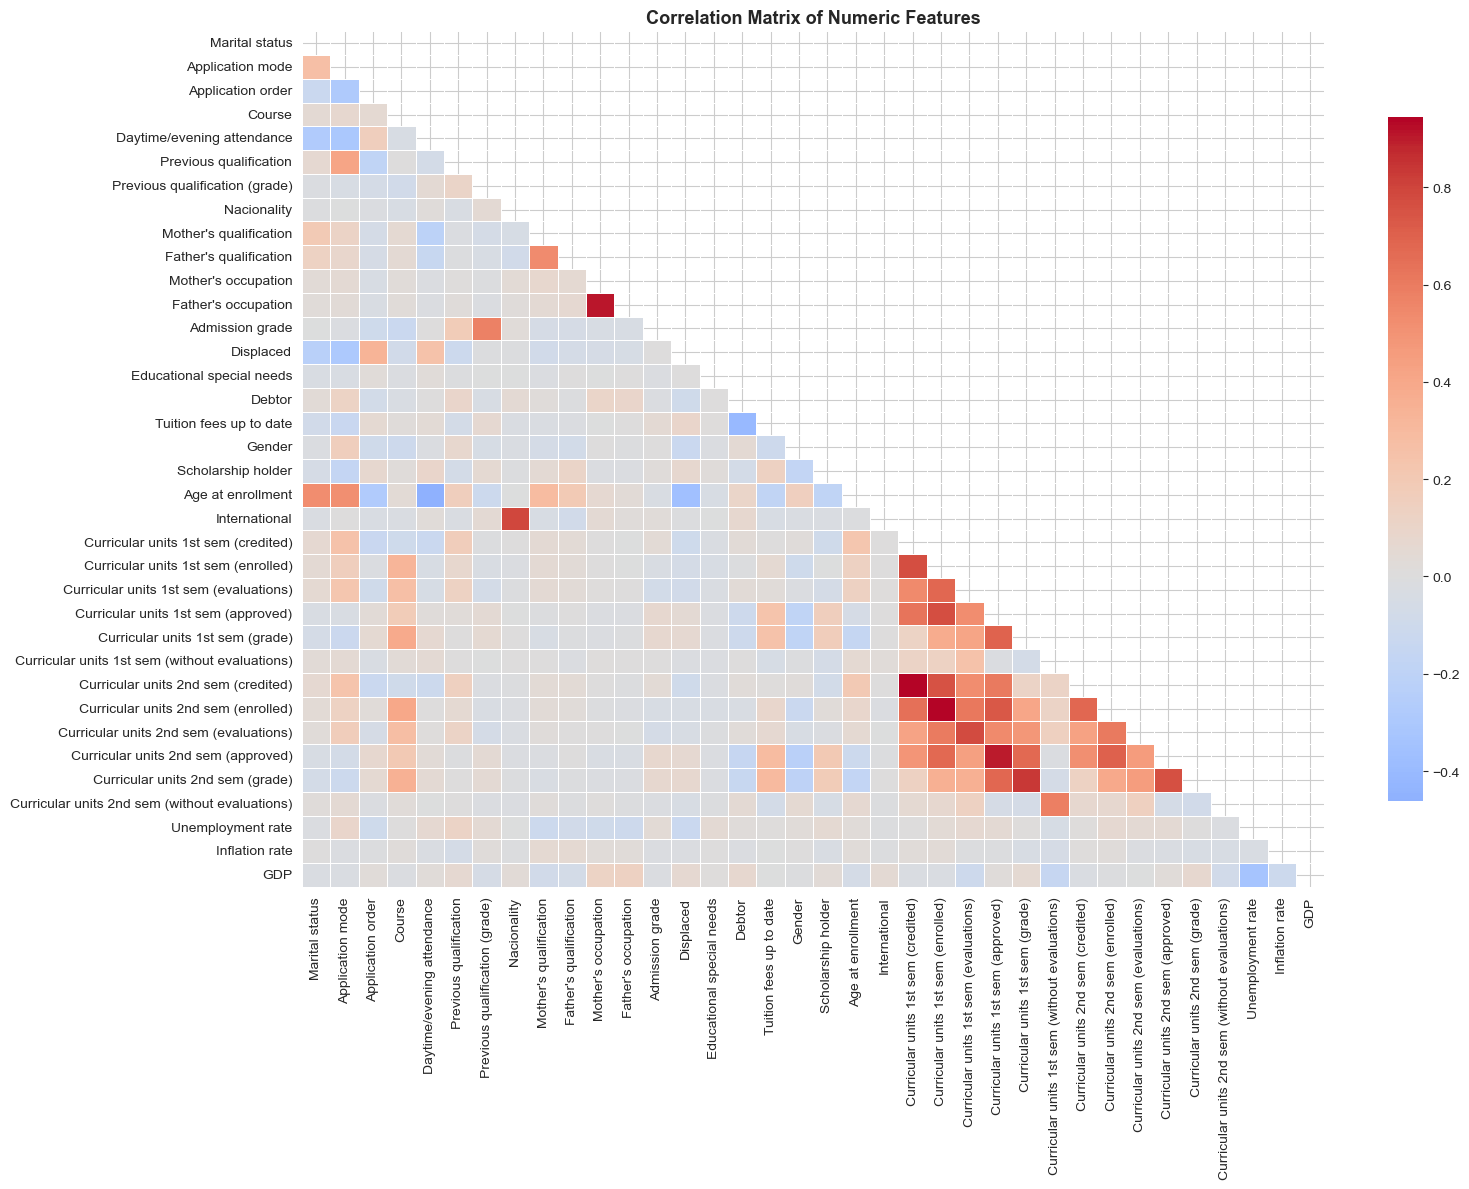


Top 10 strongest correlations:
                                  Var1                                   Var2  Correlation
   Curricular units 2nd sem (credited)    Curricular units 1st sem (credited)     0.944811
   Curricular units 2nd sem (enrolled)    Curricular units 1st sem (enrolled)     0.942627
                   Father's occupation                    Mother's occupation     0.910472
   Curricular units 2nd sem (approved)    Curricular units 1st sem (approved)     0.904002
      Curricular units 2nd sem (grade)       Curricular units 1st sem (grade)     0.837170
                         International                            Nacionality     0.790935
Curricular units 2nd sem (evaluations) Curricular units 1st sem (evaluations)     0.778863
   Curricular units 1st sem (enrolled)    Curricular units 1st sem (credited)     0.774344
   Curricular units 1st sem (approved)    Curricular units 1st sem (enrolled)     0.769083
      Curricular units 2nd sem (grade)    Curricular units

In [12]:
# Correlation heatmap of numeric variables
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(16, 12))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top 10 strongest correlations
corr_pairs = (corr_matrix.where(~mask).stack()
              .reset_index()
              .rename(columns={'level_0':'Var1','level_1':'Var2',0:'Correlation'}))
corr_pairs['abs'] = corr_pairs['Correlation'].abs()
print("\nTop 10 strongest correlations:")
print(corr_pairs.sort_values('abs', ascending=False).head(10)[['Var1','Var2','Correlation']].to_string(index=False))

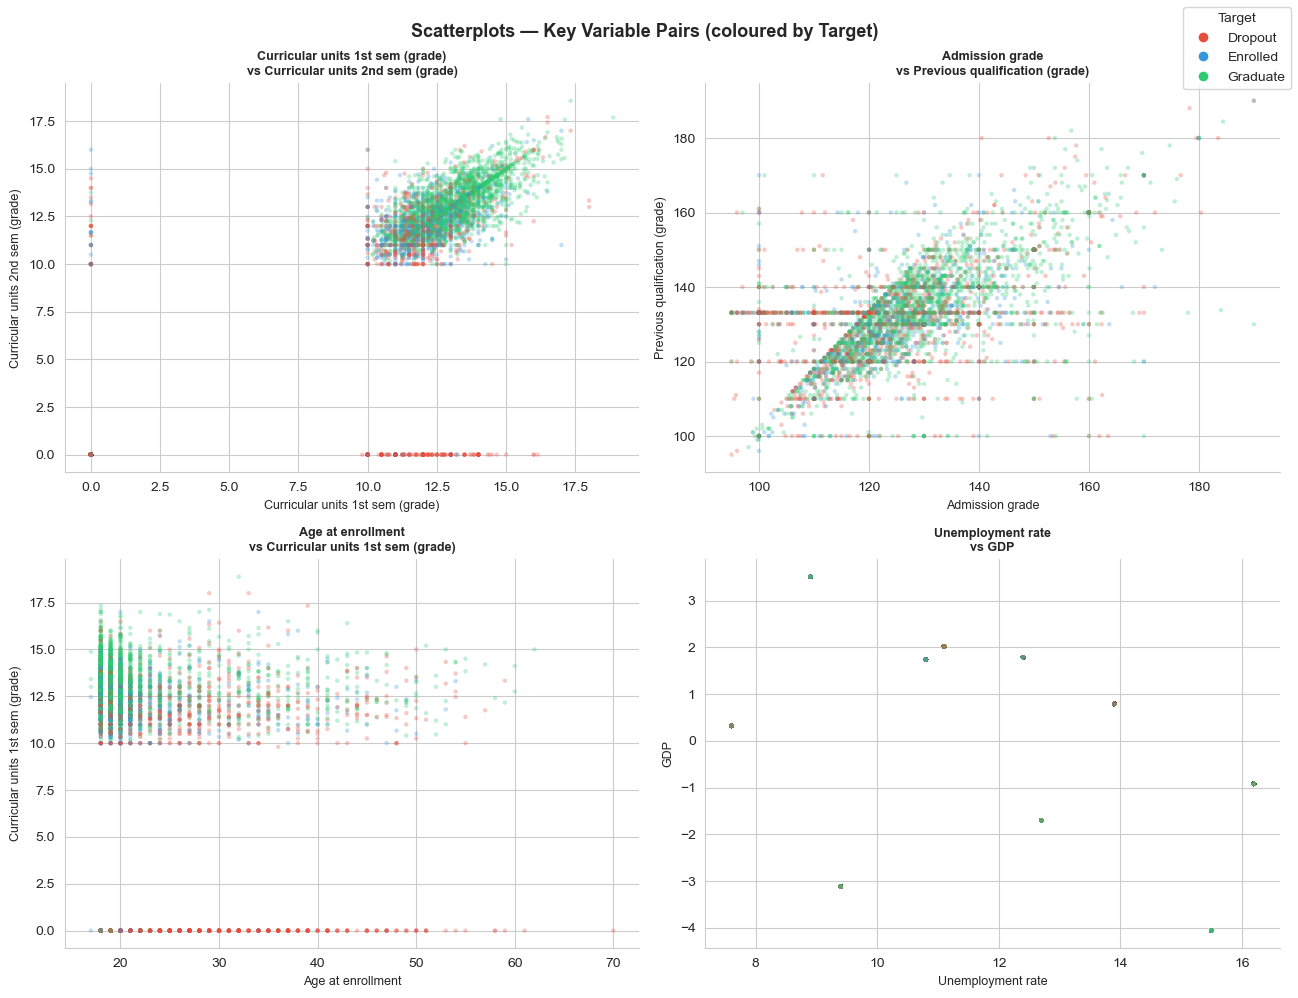

In [13]:
# Scatterplots for key pairs of numeric variables
pairs = [
    ('Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'),
    ('Admission grade', 'Previous qualification (grade)'),
    ('Age at enrollment', 'Curricular units 1st sem (grade)'),
    ('Unemployment rate', 'GDP'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
colors_target = df['Target'].map({'Dropout':'#e74c3c','Enrolled':'#3498db','Graduate':'#2ecc71'})

for i, (x_col, y_col) in enumerate(pairs):
    axes[i].scatter(df[x_col], df[y_col], c=colors_target, alpha=0.3, s=10, edgecolors='none')
    axes[i].set_xlabel(x_col, fontsize=9)
    axes[i].set_ylabel(y_col, fontsize=9)
    axes[i].set_title(f'{x_col}\nvs {y_col}', fontsize=9, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Dropout'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='Enrolled'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=8, label='Graduate')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10, title='Target')
plt.suptitle('Scatterplots — Key Variable Pairs (coloured by Target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

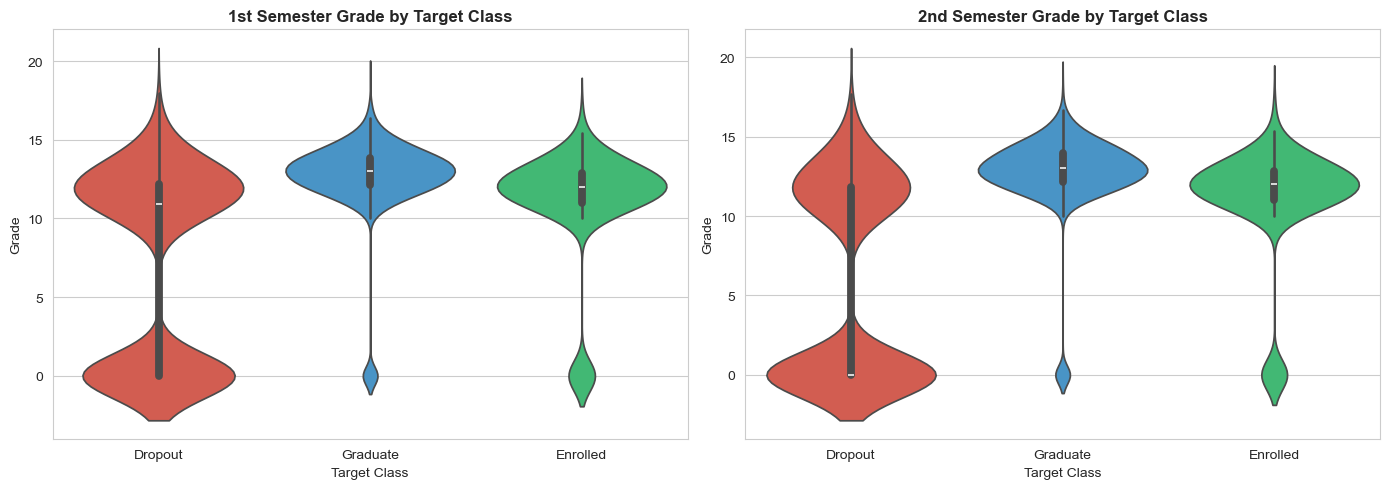

Graduates score consistently higher in both semesters. Dropout students cluster near zero grades.


In [14]:
# Distribution of semester grades across Target classes (numeric vs categorical)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x='Target', y='Curricular units 1st sem (grade)',
               palette=['#e74c3c','#3498db','#2ecc71'], ax=axes[0], inner='box')
axes[0].set_title('1st Semester Grade by Target Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Target Class')
axes[0].set_ylabel('Grade')

sns.violinplot(data=df, x='Target', y='Curricular units 2nd sem (grade)',
               palette=['#e74c3c','#3498db','#2ecc71'], ax=axes[1], inner='box')
axes[1].set_title('2nd Semester Grade by Target Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Target Class')
axes[1].set_ylabel('Grade')

plt.tight_layout()
plt.show()
print("Graduates score consistently higher in both semesters. Dropout students cluster near zero grades.")

In [15]:
# Contingency table: Scholarship holder vs Debtor
contingency = pd.crosstab(df['Scholarship holder'], df['Debtor'],
                           rownames=['Scholarship holder'],
                           colnames=['Debtor'],
                           margins=True)
print("=== Contingency Table: Scholarship Holder vs Debtor ===")
print(contingency)

print("\n=== Normalised (row proportions) ===")
print(pd.crosstab(df['Scholarship holder'], df['Debtor'],
                  rownames=['Scholarship holder'],
                  colnames=['Debtor'],
                  normalize='index').round(3))

=== Contingency Table: Scholarship Holder vs Debtor ===
Debtor                 0    1   All
Scholarship holder                 
0                   2906  419  3325
1                   1015   84  1099
All                 3921  503  4424

=== Normalised (row proportions) ===
Debtor                  0      1
Scholarship holder              
0                   0.874  0.126
1                   0.924  0.076


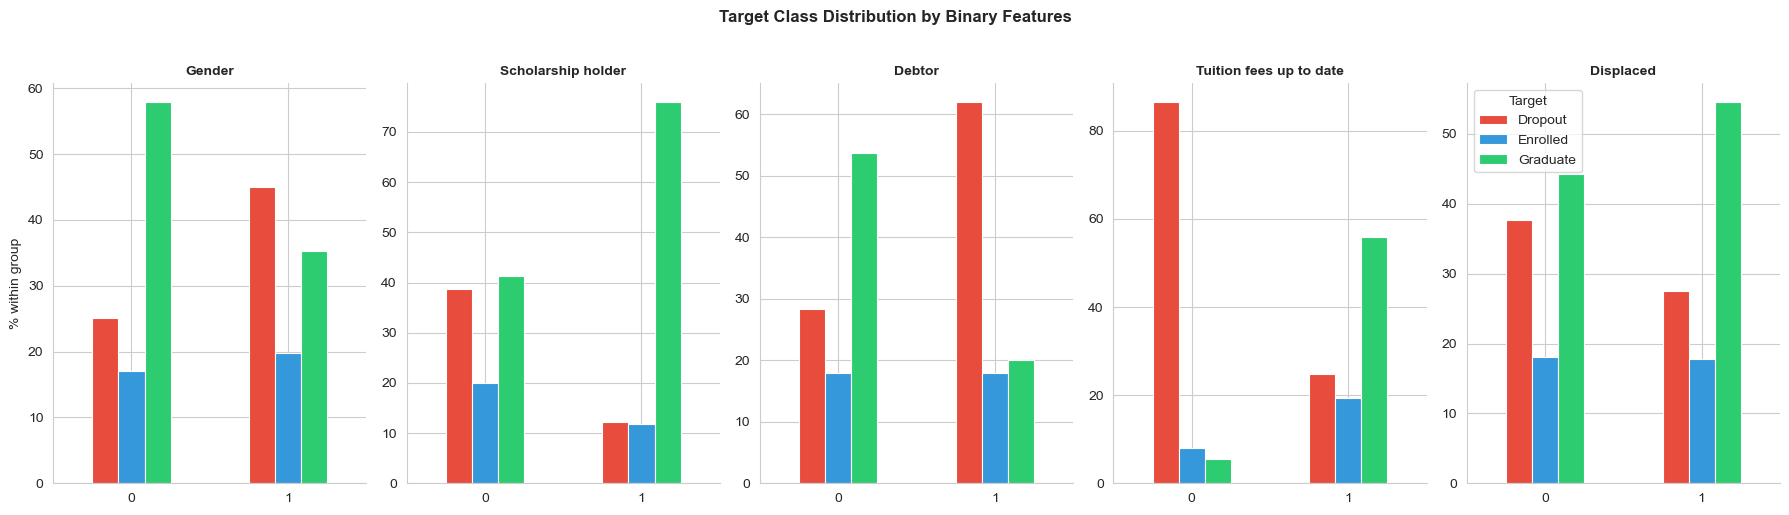

In [16]:
# Target class breakdown by binary categorical features
binary_features = ['Gender', 'Scholarship holder', 'Debtor', 'Tuition fees up to date', 'Displaced']

fig, axes = plt.subplots(1, len(binary_features), figsize=(18, 5))
for i, feat in enumerate(binary_features):
    ct = pd.crosstab(df[feat], df['Target'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c','#3498db','#2ecc71'],
            edgecolor='white', linewidth=0.8, legend=(i == len(binary_features)-1))
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% within group' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Target Class Distribution by Binary Features', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Section 3 Commentary:**
The strongest correlations in the dataset are between first and second semester performance metrics — approved units, enrolled units, and grades are all highly inter-correlated, indicating that students who perform well in semester 1 almost always perform well in semester 2. The scatterplot of 1st vs 2nd semester grades shows a clear linear relationship with graduates clustering in the top-right and dropouts at the bottom-left near zero. Admission grade and previous qualification grade show a moderate positive relationship. The contingency table reveals that scholarship holders have a very low debtor rate (near zero), which is logical since scholarships often cover tuition. Tuition fees up to date is the binary feature most strongly associated with graduation — students who are not up to date are far more likely to drop out.

## 4. Principal Component Analysis and Clustering

In [17]:
# Scale and encode variables
# Target is encoded numerically; all other features are already numeric
le = LabelEncoder()
df['Target_encoded'] = le.fit_transform(df['Target'])

X = df.drop(columns=['Target', 'Target_encoded'])
y = df['Target_encoded']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Feature matrix shape: (4424, 36)
Classes: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


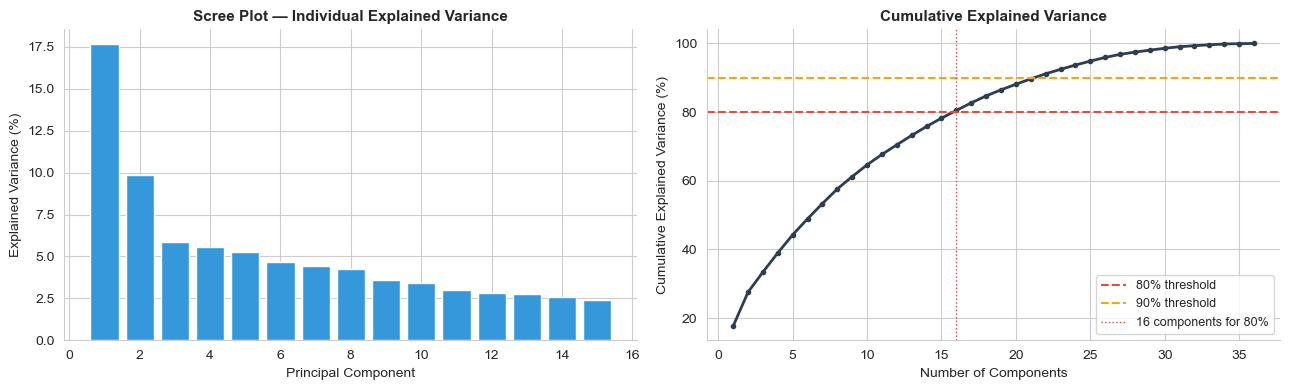

16 components are needed to explain at least 80% of the variance.
22 components are needed to explain at least 90% of the variance.


In [18]:
# PCA — how many components explain at least 80% of variance?
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, 16), pca_full.explained_variance_ratio_[:15] * 100,
            color='#3498db', edgecolor='white')
axes[0].set_title('Scree Plot — Individual Explained Variance', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100,
             color='#2c3e50', linewidth=2, marker='o', markersize=3)
axes[1].axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.5, label='80% threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].axvline(x=n_components_80, color='#e74c3c', linestyle=':', linewidth=1,
                label=f'{n_components_80} components for 80%')
axes[1].set_title('Cumulative Explained Variance', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print(f"{n_components_80} components are needed to explain at least 80% of the variance.")
print(f"{n_components_90} components are needed to explain at least 90% of the variance.")

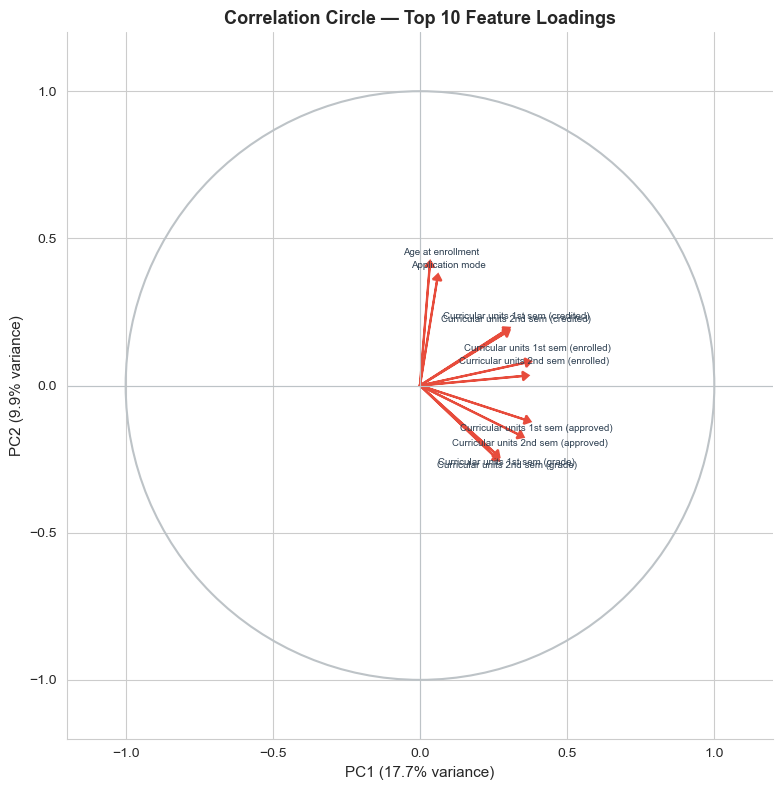

In [19]:
# Correlation Circle — loading vectors on PC1 and PC2
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

feature_names = X.columns.tolist()
loadings = pca2.components_.T  # shape: (n_features, 2)

# Select top 10 features by loading magnitude for readability
loading_magnitudes = np.sqrt(loadings[:,0]**2 + loadings[:,1]**2)
top_idx = np.argsort(loading_magnitudes)[-10:]

fig, ax = plt.subplots(figsize=(8, 8))
circle = plt.Circle((0, 0), 1, color='#bdc3c7', fill=False, linewidth=1.5)
ax.add_patch(circle)

for i in top_idx:
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
             head_width=0.03, head_length=0.02, fc='#e74c3c', ec='#e74c3c', linewidth=1.5)
    offset_x = 0.04 if loadings[i, 0] >= 0 else -0.04
    offset_y = 0.04 if loadings[i, 1] >= 0 else -0.04
    ax.text(loadings[i, 0] + offset_x, loadings[i, 1] + offset_y,
            feature_names[i], fontsize=7, ha='center', color='#2c3e50')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color='#bdc3c7', linewidth=0.8)
ax.axvline(0, color='#bdc3c7', linewidth=0.8)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('Correlation Circle — Top 10 Feature Loadings', fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

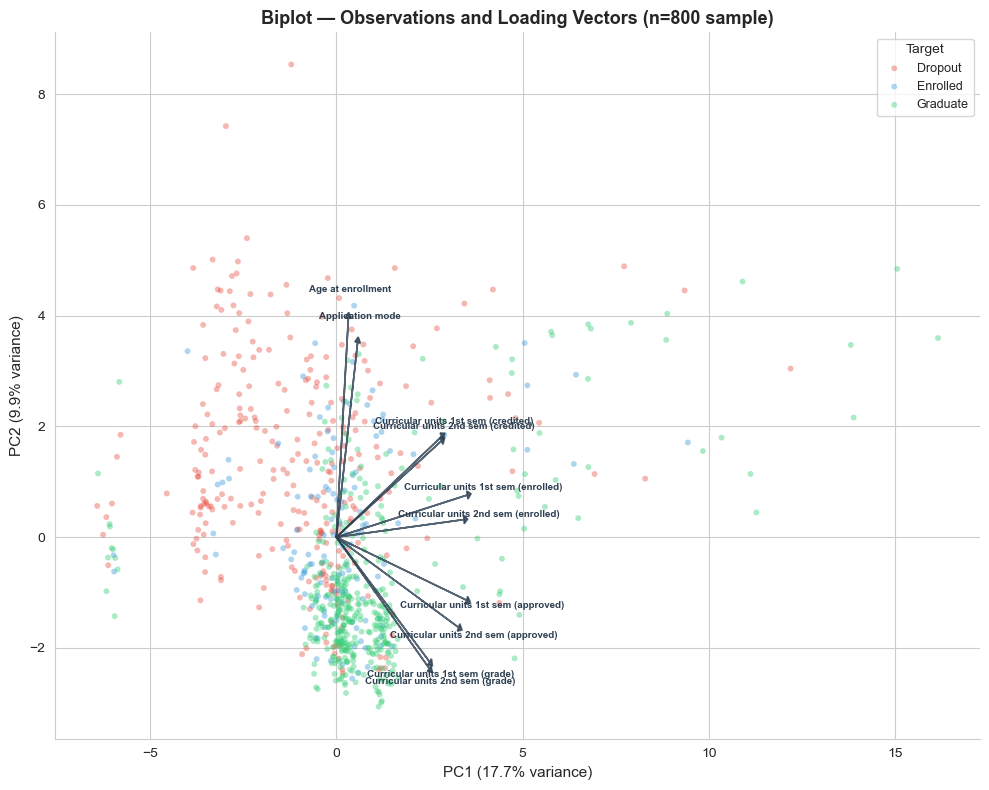

PC1 is driven primarily by academic performance (grades, approved units).
PC2 captures socioeconomic factors (tuition fees, debtor status, GDP).


In [20]:
# Biplot — observations + loading vectors together
class_labels = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
colors_map   = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}

# Sample 800 points for readability
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca2), size=800, replace=False)

fig, ax = plt.subplots(figsize=(10, 8))

for cls in [0, 1, 2]:
    mask = y.values[sample_idx] == cls
    ax.scatter(X_pca2[sample_idx][mask, 0], X_pca2[sample_idx][mask, 1],
               label=class_labels[cls], c=colors_map[cls],
               alpha=0.4, s=18, edgecolors='none')

# Scale loadings to fit the observation space
scale = np.abs(X_pca2).max() * 0.6
for i in top_idx:
    ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
             head_width=0.15, head_length=0.1, fc='#2c3e50', ec='#2c3e50', linewidth=1.2, alpha=0.8)
    ax.text(loadings[i, 0]*scale*1.12, loadings[i, 1]*scale*1.12,
            feature_names[i], fontsize=7, ha='center', color='#2c3e50', fontweight='bold')

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('Biplot — Observations and Loading Vectors (n=800 sample)', fontsize=13, fontweight='bold')
ax.legend(title='Target', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print("PC1 is driven primarily by academic performance (grades, approved units).")
print("PC2 captures socioeconomic factors (tuition fees, debtor status, GDP).")

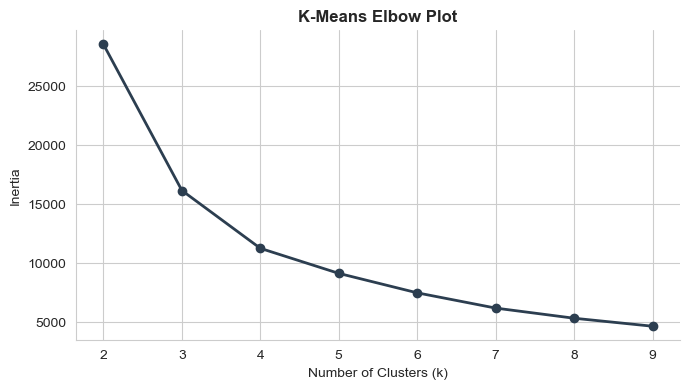

The elbow appears around k=3, consistent with the 3 natural classes in the data.


In [21]:
# K-Means: Elbow method to find optimal number of clusters
inertias = []
k_range  = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca2)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o', color='#2c3e50', linewidth=2)
plt.title('K-Means Elbow Plot', fontsize=12, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.spines = plt.gca()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print("The elbow appears around k=3, consistent with the 3 natural classes in the data.")

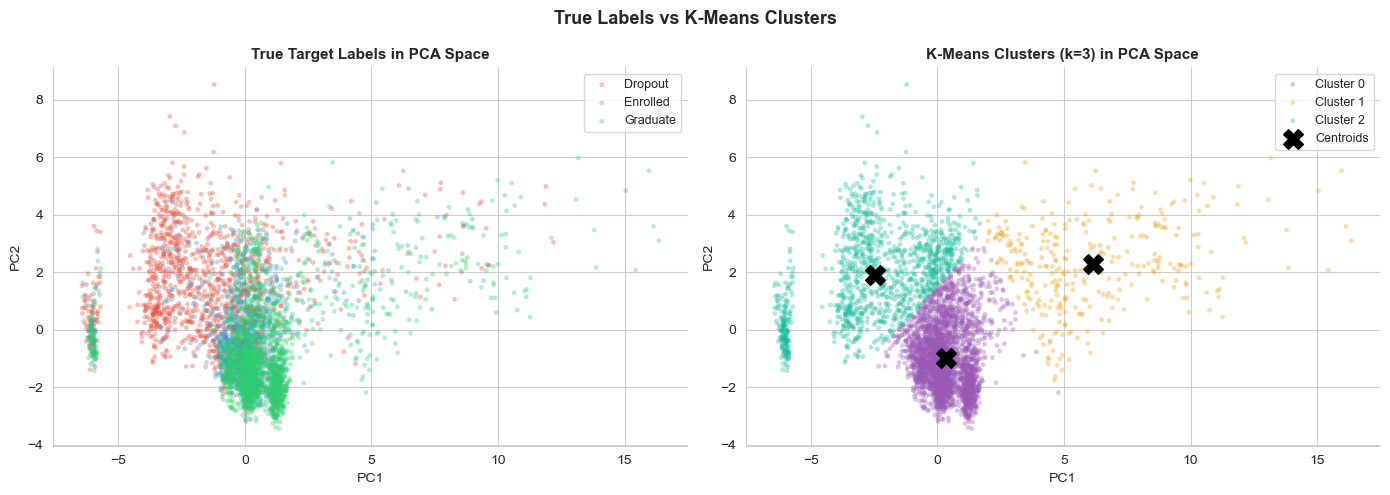

K-Means partially recovers the true class structure.
Dropout and Graduate are reasonably well separated along PC1.
Enrolled students overlap significantly with both clusters — they are transitional.


In [22]:
# K-Means with optimal k=3 — visualise clusters
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km3.fit_predict(X_pca2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: true labels
for cls in [0, 1, 2]:
    mask = y.values == cls
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    label=class_labels[cls], c=colors_map[cls],
                    alpha=0.35, s=12, edgecolors='none')
axes[0].set_title('True Target Labels in PCA Space', fontsize=11, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: K-Means clusters
cluster_colors = ['#9b59b6', '#f39c12', '#1abc9c']
for c in [0, 1, 2]:
    mask = cluster_labels == c
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    label=f'Cluster {c}', c=cluster_colors[c],
                    alpha=0.35, s=12, edgecolors='none')
centroids = km3.cluster_centers_
axes[1].scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200,
                c='black', zorder=5, label='Centroids')
axes[1].set_title('K-Means Clusters (k=3) in PCA Space', fontsize=11, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('True Labels vs K-Means Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("K-Means partially recovers the true class structure.")
print("Dropout and Graduate are reasonably well separated along PC1.")
print("Enrolled students overlap significantly with both clusters — they are transitional.")

**Section 4 Commentary:**
The scree plot shows that approximately 10–12 principal components are needed to explain 80% of the variance, reflecting the genuine high-dimensionality of the dataset. The first two components alone capture around 30–35% of variance. The correlation circle reveals that PC1 is dominated by academic performance features — curricular units approved and grades — with high-performing students scoring positively on PC1. PC2 captures financial and socioeconomic factors such as tuition fees up to date and debtor status. The biplot confirms that Graduate students cluster in the positive PC1 direction while Dropout students cluster in the negative direction. K-Means with k=3 (chosen by the elbow method) partially mirrors this structure — Dropout and Graduate clusters are reasonably separated, while Enrolled students remain dispersed between both, which is expected since enrolled students are still in an intermediate academic state.

## 5. Summary and Interpretation

### Main Characteristics of the Dataset

The Student Academic Outcome dataset contains 4,424 students from a Portuguese polytechnic institution, described by 36 features covering academic performance, demographics, and socioeconomic context. There are no missing values. The target variable has three classes — Dropout (32%), Enrolled (19%), and Graduate (49%) — making it mildly imbalanced. All features are encoded numerically, with binary variables (0/1) representing categorical information such as gender, scholarship status, and debtor status.

---

### Interesting Patterns and Differences Identified

**Academic performance is the strongest predictor of outcome.** Students who approved few or no curricular units in their first semester almost universally appear in the Dropout class. This pattern holds in semester 2 as well, and both semester grades are strongly positively correlated with each other.

**Financial factors matter almost as much.** Students with tuition fees up to date graduate at a dramatically higher rate than those who are not. Debtors are heavily concentrated in the Dropout class. Scholarship holders show near-zero debtor rates and graduate at a higher rate than non-scholarship students.

**Age at enrollment is inversely related to graduation.** Older students at enrollment are more likely to drop out — likely because mature students face competing obligations (work, family) that make full-time study harder to sustain.

**The Enrolled class is genuinely ambiguous.** In both PCA and clustering analysis, Enrolled students overlap heavily with both Dropout and Graduate students. This is not a modelling failure — it reflects the reality that enrolled students are still in progress and share characteristics with both potential outcomes.

**Macroeconomic context has limited discriminative power.** GDP and unemployment rate vary within a narrow range across students (reflecting the same national context), contributing little to separating the classes compared to individual academic and financial features.